# Quantization Aware Training + Knowledge Distillation

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch.utils.data import DataLoader
from typing import Callable

from src.utils import load_data, process_callbacks
from src.Quantization.utils.model_setup import qat_kd_setup, setup_qat_student_model
from src.utils import compute_loss_and_predictions, calculate_metrics, plot_train_val_curve, test_inference
from src.utils import model_size, measure_inference_performance, calculate_speedup, measure_memory_usage


In [2]:
# Specify random seed for repeatable results
_ = torch.manual_seed(191009)

### Helper Functions

In [3]:
def load_quantized_model(model_path: str, device: torch.device = torch.device("cpu")) -> torch.jit.ScriptModule:
    """
    Loads a quantized TorchScript model from the specified file.

    Parameters:
        model_path (str): Path to the saved TorchScript model (.pt file).
        device (torch.device): The device on which to load the model. Defaults to CPU.
    
    Returns:
        torch.jit.ScriptModule: The loaded quantized model.
    """
    # Load the TorchScript model from disk, mapping it to the specified device.
    model = torch.jit.load(model_path, map_location=device)
    # Set the model to evaluation mode (important for inference)
    model.eval()
    return model

def compute_distillation_loss(teacher_logits: torch.Tensor, student_logits: torch.Tensor, T: float) -> torch.Tensor:
    """
    Computes the distillation loss using KL divergence with softened logits.

    Parameters:
        teacher_logits (torch.Tensor): Logits from the teacher model.
        student_logits (torch.Tensor): Logits from the student model.
        T (float): Temperature to soften the logits.

    Returns:
        torch.Tensor: The computed distillation loss.
    """
    soft_loss = F.kl_div(
        F.log_softmax(student_logits / T, dim=1),
        F.softmax(teacher_logits / T, dim=1),
        reduction='batchmean'
    ) * (T ** 2)
    return soft_loss

In [4]:
# model = torch.ao.quantization.convert(model.eval(), inplace=False)
# print_model_size(model)

# torch.jit.save(torch.jit.script(model), "../../mobilenetv2_quantized.pt")

# model_test = load_quantized_model("../../mobilenetv2_quantized.pt")

In [5]:
def train_knowledge_distillation(
    teacher: nn.Module,
    student: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    learning_rate: float,
    epochs: int,
    criterion: Callable[[torch.Tensor, torch.Tensor], torch.Tensor],
    optimizer: torch.optim.Optimizer,
    callbacks,
    T: float,
    soft_target_loss_weight: float,
    ce_loss_weight: float,
    device: torch.device
) -> None:
    """
    Trains the student model using knowledge distillation from the teacher model.
    The loss is a weighted sum of the KL divergence (distillation loss) and the standard cross entropy loss.
    Validation is performed at the end of each epoch.
    
    Parameters:
        teacher (nn.Module): The pre-trained teacher model.
        student (nn.Module): The student model to be trained.
        train_loader (DataLoader): DataLoader for the training dataset.
        val_loader (DataLoader): DataLoader for the validation dataset.
        learning_rate (float): Learning rate used for logging
        epochs (int): Number of training epochs.
        criterion (Callable): Loss function for the true label loss (e.g., nn.CrossEntropyLoss).
        optimizer (torch.optim.Optimizer): Optimizer for updating the student model parameters.
        T (float): Temperature for softening the logits.
        soft_target_loss_weight (float): Weight for the distillation (soft targets) loss.
        ce_loss_weight (float): Weight for the cross entropy loss on true labels.
        device (torch.device): Device to perform training on.
    """
    loss_dict = {'train': [], 'val': []}
    # Set teacher to evaluation mode (its parameters won't be updated)
    teacher.eval()
    
    for epoch in range(epochs):
        logs = {"model": student, 
                "batch_size": train_loader.batch_size, 
                "learning_rate": learning_rate, 
                "optimizer": optimizer,
                "criterion": criterion,
                "epoch": epoch}

        # Trigger on_epoch_start callbacks
        for callback in callbacks:
            callback.on_epoch_start(epoch, logs)

        for phase in ['train', 'val']:
            is_train = phase == 'train'
            student.train() if is_train else student.eval()
            data_loader = train_loader if is_train else val_loader

            running_loss = 0.0
            total_samples  = 0.0
            predictions, ground_truths, probabilities = [], [], []

            with tqdm(total=len(data_loader), desc=f"{phase.capitalize()} Epoch {epoch + 1}/{epochs}") as pbar:
                for inputs, labels in data_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    
                    # Zero gradients only during training
                    if is_train:
                        optimizer.zero_grad()
                    
                    # Teacher forward pass without gradient computation.
                    with torch.no_grad():
                        teacher = teacher.to(device)
                        teacher_logits = teacher(inputs)
                    
                    # Enable gradients only in training phase
                    with torch.set_grad_enabled(is_train):
                        student = student.to(device)
                        # Student forward pass.
                        student_logits = student(inputs)

                        # Compute soft targets loss using KL divergence.
                        # Using 'batchmean' ensures the loss is averaged over the batch.
                        soft_loss = compute_distillation_loss(teacher_logits=teacher_logits, student_logits=student_logits, T=T)

                        # Compute the true label loss and obtain predictions/probabilities
                        label_loss, probs, preds = compute_loss_and_predictions(student_logits, labels, criterion)
                        
                        # Compute weighted combination of the distillation and cross entropy losses
                        loss = soft_target_loss_weight * soft_loss + ce_loss_weight * label_loss

                        # Backward pass and optimizer step in training phase
                        if is_train:
                            loss.backward()
                            optimizer.step()
                    
                    # Update running loss and sample count
                    batch_size = inputs.size(0)
                    running_loss += loss.item() * batch_size
                    total_samples += batch_size

                    # Accumulate predictions and ground truths for metrics
                    ground_truths.extend(labels.cpu().detach().numpy())
                    predictions.extend(preds.cpu().detach().numpy())
                    probabilities.extend(probs.cpu().detach().numpy())
                    
                    # Update progress bar with average loss so far
                    pbar.set_postfix(loss=f"{running_loss / total_samples:.4f}")
                    pbar.update(1)
                
            # Compute aggregated metrics after epoch
            epoch_loss = running_loss / total_samples
            
            y_true = np.array(ground_truths)
            y_pred = np.array(predictions)
            y_proba = np.array(probabilities) if probabilities else None

            # Calculate metrics
            metrics = calculate_metrics(y_true, y_pred, y_proba)

            loss_dict[phase].append(epoch_loss)
            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f}")
            print(f"{phase.capitalize()} Metrics: " + ", ".join([f"{key}: {value:.4g}" for key, value in metrics.items()]))
            logs.update({f"{phase}_loss": epoch_loss, **metrics})

        # Trigger on_epoch_end callbacks
        for callback in callbacks:
            callback.on_epoch_end(epoch, logs)

        # Check for early stopping
        if any(getattr(cb, "early_stop", False) for cb in callbacks):
            break

    return loss_dict

In [6]:
def train_qat_kd(
    teacher_name: str,
    student_name: str,
    data_loaders: dict[str, DataLoader],
    save_dir: str,
    learning_rate: float = 0.001,
    epochs: int = 5,
    criterion: str = "cross_entropy",
    optimizer: str = "adam",
    callbacks: list = None,
    teacher_model_weights: str = None,
    quant_mode: str = "fx",
    config: str = "qnnpack",
    class_weights: bool = False,
):
    """
    Trains a student model using Knowledge Distillation (KD) and Quantization-Aware Training (QAT).
    
    This function sets up both the teacher and student models, prepares the student model for 
    QAT, and trains it using knowledge distillation. The function also manages training callbacks, 
    saves checkpoints, and evaluates the final quantized model.

    Parameters:
        teacher_name (str): Name of the pre-trained teacher model (e.g., 'resnet50', 'efficientnet_b0').
        student_name (str): Name of the student model to be trained with QAT.
        data_loaders (dict[str, DataLoader]): Dictionary containing DataLoaders for dataset splits 
                                              (keys: 'train', 'val', optional 'test').
        save_dir (str): Directory where the trained model, checkpoints, and metrics will be saved.
        learning_rate (float, optional): Learning rate for the optimizer. Defaults to 0.001.
        epochs (int, optional): Number of training epochs. Defaults to 5.
        criterion (str, optional): Loss function to use (e.g., 'cross_entropy', 'bce'). Defaults to 'cross_entropy'.
        optimizer (str, optional): Optimizer to use (e.g., 'adam', 'sgd'). Defaults to 'adam'.
        callbacks (list, optional): List of callback functions for monitoring and checkpointing during training. Defaults to None.
        teacher_model_weights (str, optional): Path to pre-trained weights for the teacher model. Defaults to None.
        quant_mode (str, optional): Quantization mode, either 'eager' or 'fx'. Defaults to 'fx'.
        config (str, optional): QAT configuration identifier ('qnnpack' for default qnnpack QAT config or custom). Defaults to 'qnnpack'.
        class_weights (bool, optional): Whether to compute and apply class weights to handle class imbalance. Defaults to False.

    Returns:
        Tuple[nn.Module, nn.Module]: The trained teacher and student models.

    Notes:
        - The student model undergoes quantization-aware training.
        - Knowledge distillation is applied with temperature scaling (T=2) and weighted loss terms.
        - If a test DataLoader is provided, final inference evaluation is performed.
    """
    # Load dataset
    # logging.info("Loading datasets...")
    train_loader = data_loaders["train"]
    val_loader = data_loaders["val"]
    # logging.info("Datasets loaded successfully.")

    # Device configuration - quantization is often done on CPU.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    teacher, student, criterion, optimizer = qat_kd_setup(teacher=teacher_name, 
                                                          student=student_name,
                                                          learning_rate=learning_rate, 
                                                          criterion=criterion, 
                                                          optimizer=optimizer, 
                                                          teacher_model_weights=teacher_model_weights, 
                                                          dataloader=train_loader, 
                                                          quant_mode=quant_mode,
                                                          config=config,
                                                          class_weights=class_weights,
                                                          device=device)

    # Initialize variables for checkpointing
    quantized_model_path = os.path.join(save_dir, f"{student_name}_test.pth")
    metrics_save_dir = os.path.join(save_dir, "metrics")
    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(metrics_save_dir, exist_ok=True)
    # logging.info(f"Training will save checkpoints to: {save_dir}")

    for callback in callbacks:
        callback.on_train_start(logs={})

    # Training loop
    # logging.info("Starting training...")
    # start = time.time()

    # Train the student model using knowledge distillation.
    loss_dict = train_knowledge_distillation(
                            teacher=teacher, 
                            student=student, 
                            train_loader=train_loader,
                            val_loader=val_loader,
                            learning_rate=learning_rate,
                            epochs=epochs, 
                            criterion=criterion,
                            optimizer=optimizer,
                            callbacks=callbacks,
                            T=2, 
                            soft_target_loss_weight=0.25, 
                            ce_loss_weight=0.75, 
                            device=device
                        )

    # time_elapsed = time.time() - start
    # logging.info(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")

    # Trigger training end callbacks
    for callback in callbacks:
        callback.on_train_end(logs={"model": student, "optimizer": optimizer})

    # Load the best model weights before returning
    model_data = torch.load(quantized_model_path, weights_only=True)
    student.load_state_dict(model_data)
    # logging.info(f"Best model weights loaded from: {quantized_model_path}")
    plot_train_val_curve(loss_dict, save_path=os.path.join(metrics_save_dir, "loss_curve.png"))

    if data_loaders["test"]:
        test_inference(student, data_loaders["test"], device, metrics_save_dir)

    return teacher, student

### Hyperparameters

c:\Users\jacob\Documents\Uni\Research-EdgeML\EdgeComputingGroup\model-compression\src\utils\model_setup.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = tor

Model prepared using FX Graph Mode QAT.


Train Epoch 1/1: 100%|██████████| 917/917 [18:22<00:00,  1.20s/it, loss=0.8392]


Train Loss: 0.8392
Train Metrics: Accuracy: 0.696, Recall: 0.5064, Precision: 0.6201, F1-Score: 0.5272, AUC-Score: 0.9431


Val Epoch 1/1: 100%|██████████| 115/115 [01:56<00:00,  1.01s/it, loss=0.7856]
c:\Users\jacob\anaconda3\envs\ECG\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Val Loss: 0.7856
Val Metrics: Accuracy: 0.7199, Recall: 0.5749, Precision: 0.6237, F1-Score: 0.5877, AUC-Score: 0.9622


Inference Progress: 100%|██████████| 115/115 [01:39<00:00,  1.15it/s]
c:\Users\jacob\anaconda3\envs\ECG\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Metrics Results:
Accuracy: 0.7052
Recall: 0.5501
Precision: 0.6160
F1-Score: 0.5675
AUC-Score: 0.9575


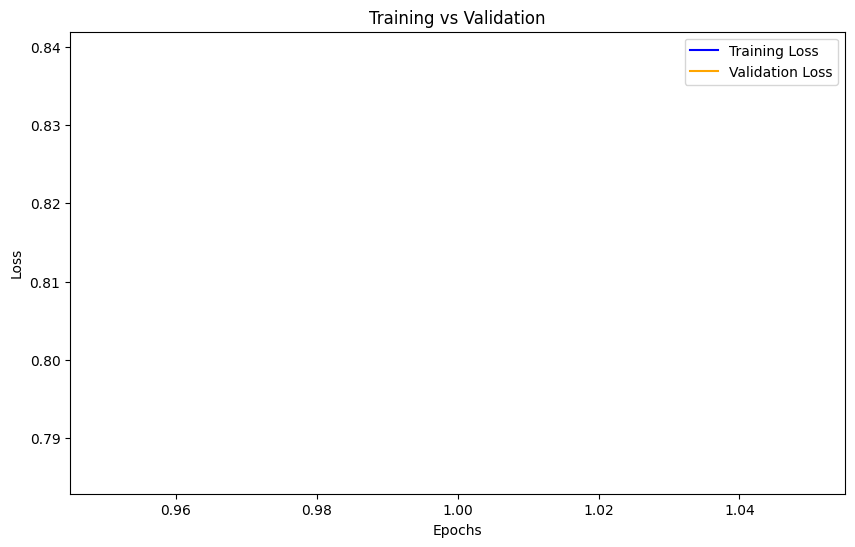

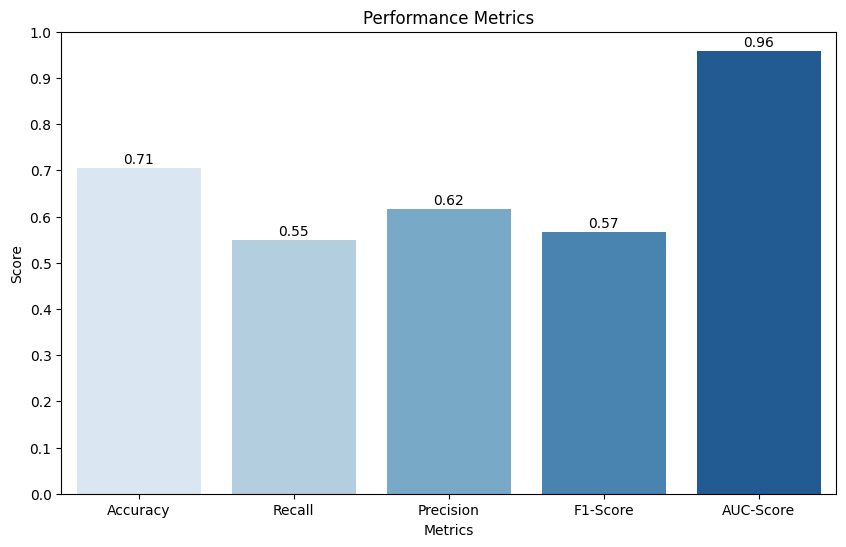

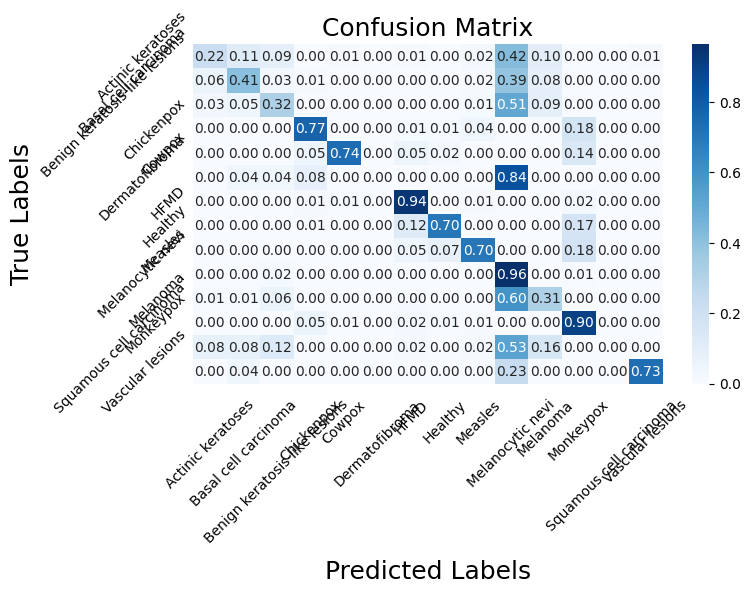

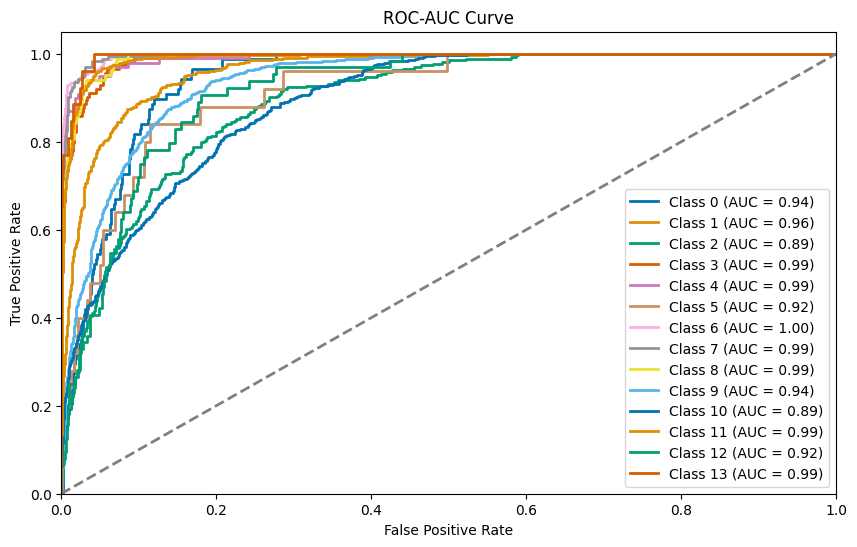

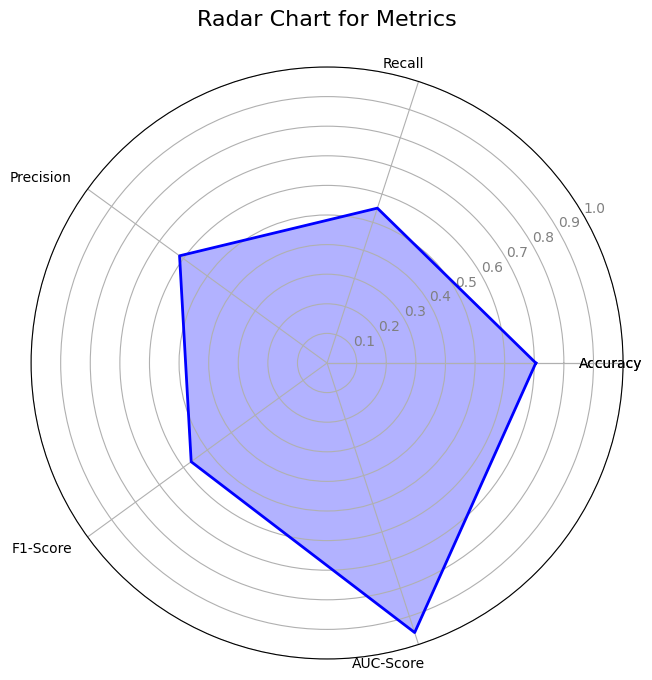

In [7]:
dataset = "SkinCancer"
batch_size = 32
learning_rate = 0.001
epochs = 1
save_dir = f"models/{dataset}/Quantized"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher_model = "mobilenet_v2"
student_model = "mobilenet_v2"
args = {"callbacks": ["ModelCheckpoint", "EarlyStopping", "ReduceLROnPlateau"], 
        "save_dir": save_dir, 
        "model_name": student_model,
        "save_name": "test"}
CALLBACKS = list(process_callbacks(args).values())

os.makedirs(save_dir, exist_ok=True)

dataloaders = load_data(dataset=dataset, batch_size=batch_size)

teacher_model_weights = 'models/SkinCancer/mobilenet_v2_best_model.pth'  # Update with your saved model weights

criterion = "cross_entropy"
optimizer = "adam"

teacher, student = train_qat_kd(
                                teacher_name=teacher_model, 
                                student_name=student_model,
                                data_loaders=dataloaders,
                                save_dir=save_dir,
                                learning_rate=learning_rate,
                                epochs=epochs,
                                criterion = criterion,
                                optimizer = optimizer,
                                callbacks=CALLBACKS,
                                teacher_model_weights=teacher_model_weights
                            )


In [8]:
# Measure model sizes.
# TODO: check convert fx
teacher_size = model_size(teacher)
student_size = model_size(student)

# Measure inference performance.
avg_time_teacher, throughput_teacher = measure_inference_performance(teacher, data_loader=dataloaders['test'], device=device)
avg_time_student, throughput_student = measure_inference_performance(student, data_loader=dataloaders['test'], device=device)
speedup = calculate_speedup(avg_time_teacher, throughput_teacher, avg_time_student, throughput_student)

# Measure memory usage.
memory_usage_teacher = measure_memory_usage(teacher, dataloaders['test'], device)
memory_usage_student = measure_memory_usage(student, dataloaders['test'], device)

print(f"Teacher Inference Time: {avg_time_teacher:.6f} sec, Throughput: {throughput_teacher:.2f} samples/sec")
print(f"Student Inference Time: {avg_time_student:.6f} sec, Throughput: {throughput_student:.2f} samples/sec")
print("Speedups:", speedup)
print("Teacher Memory Usage:", memory_usage_teacher)
print("Student Memory Usage:", memory_usage_student)

Model size as Pth: 9.1943 MB
Model size as Pth: 9.4843 MB
Teacher Inference Time: 0.000066 sec, Throughput: 15100.06 samples/sec
Student Inference Time: 0.000303 sec, Throughput: 3304.53 samples/sec
Speedups: {'time_speedup': 0.21884234435539834, 'throughput_speedup': 0.21884234435539834}
Teacher Memory Usage: 382.0810546875
Student Memory Usage: 530.08837890625


In [ ]:
from torch.ao.quantization.quantize_fx import convert_fx

# Set the model to evaluation mode.
student.eval()

# Convert the FX QAT model to a quantized model.
quantized_student = convert_fx(student)
print(quantized_student)

RuntimeError: Quantized cudnn conv2d is currently limited to groups = 1; received groups =32

In [ ]:
pretrained_weights = f"models/SkinCancer/Quantized/mobilenet_v2_test.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 32
learning_rate = 0.001
dataloaders = load_data(dataset="SkinCancer", batch_size=batch_size)
criterion = "cross_entropy"
optimizer = "adam"
num_classes = len(dataloaders["train"].dataset.classes)
model = setup_qat_student_model(model_name="mobilenet_v2",num_classes=num_classes)

state_dict = torch.load(pretrained_weights)
model.load_state_dict(state_dict)
